# Machine Learning


Lorem ipsum .....

what method?
result?

In [237]:
!pip install yahoofinance
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    median_absolute_error,
    explained_variance_score,
    max_error
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit

In [238]:
from google.colab import drive
drive.mount("contentdrive")

Drive already mounted at contentdrive; to attempt to forcibly remount, call drive.mount("contentdrive", force_remount=True).


XISR Price Graph:


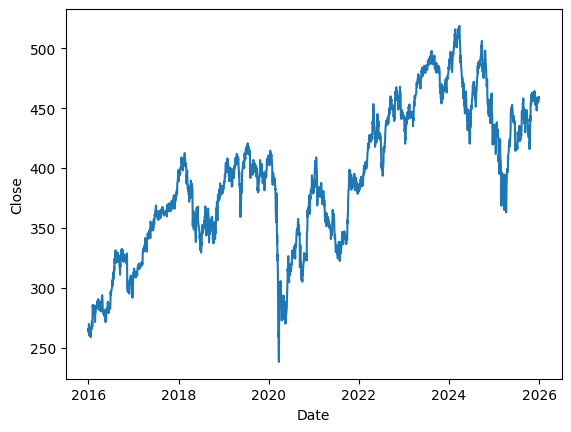


XISR Price Table:


,Ticker,Year,Date,Close,Percent_Change
0,IXISR,2015,2015-12-30,265.5348,NaN
1,IXISR,2016,2016-01-04,262.7626,-0.010440
2,IXISR,2016,2016-01-05,266.3237,0.013553
3,IXISR,2016,2016-01-06,269.8472,0.013230
4,IXISR,2016,2016-01-07,263.6682,-0.022898
...,...,...,...,...,...
2410,IXISR,2025,2025-12-22,458.6631,0.001129
2411,IXISR,2025,2025-12-23,454.6117,-0.008833
2412,IXISR,2025,2025-12-24,455.6863,0.002364
2413,IXISR,2025,2025-12-29,457.6045,0.004209


In [239]:
xisr_data = pd.read_csv("/content/contentdrive/MyDrive/ESG_Project_Data/XISR_primary_price.csv",sep=";",decimal=",")

xisr_data = xisr_data.rename(columns={
    "sec": "Ticker",
    "sdate": "Date",
    "NAV BK DB": "Close"
})

xisr_data["Date"] = pd.to_datetime(xisr_data["Date"], errors="coerce")
xisr_data["Close"] = pd.to_numeric(xisr_data["Close"], errors='coerce')

xisr_data = xisr_data.dropna(subset=["Date", "Ticker", "Close"])
xisr_data = xisr_data.sort_values("Date")

xisr_data["Percent_Change"] = xisr_data["Close"].pct_change()
xisr_data["Year"] = xisr_data["Date"].dt.year

xisr_data = xisr_data.reindex(columns=["Ticker", "Year", "Date", "Close", "Percent_Change"])

sb.lineplot(data=xisr_data, x="Date", y="Close")
print("XISR Price Graph:")
plt.show()

print("\nXISR Price Table:")
display(xisr_data)

XIIT Price Graph:


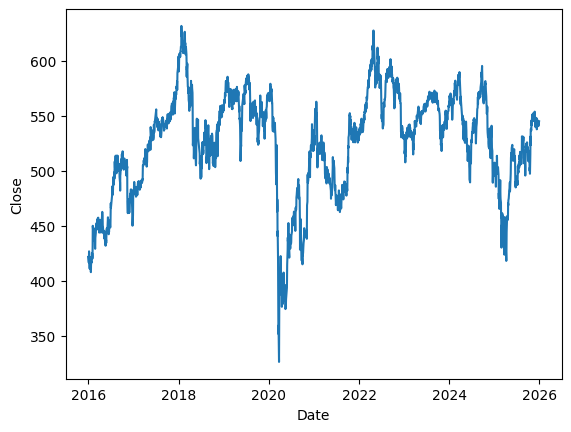


XIIT Price Table:


,Ticker,Year,Date,Close,Percent_Change
0,IXIIT,2015,2015-12-30,421.8174,NaN
1,IXIIT,2016,2016-01-04,416.5835,-0.012408
2,IXIIT,2016,2016-01-05,420.4095,0.009184
3,IXIIT,2016,2016-01-06,426.8707,0.015369
4,IXIIT,2016,2016-01-07,417.4631,-0.022039
...,...,...,...,...,...
2410,IXIIT,2025,2025-12-22,545.6347,0.003441
2411,IXIIT,2025,2025-12-23,541.3807,-0.007796
2412,IXIIT,2025,2025-12-24,540.5964,-0.001449
2413,IXIIT,2025,2025-12-29,544.6697,0.007535


In [240]:
xiit_data = pd.read_csv("/content/contentdrive/MyDrive/ESG_Project_Data/XIIT_primary_price.csv",sep=";",decimal=",")

xiit_data = xiit_data.rename(columns={
    "sec": "Ticker",
    "sdate": "Date",
    "NAV BK DB": "Close"
})

xiit_data["Date"] = pd.to_datetime(xiit_data["Date"], errors="coerce")
xiit_data["Close"] = pd.to_numeric(xiit_data["Close"], errors='coerce')

xiit_data = xiit_data.dropna(subset=["Date", "Ticker", "Close"])
xiit_data = xiit_data.sort_values("Date")

xiit_data["Percent_Change"] = xiit_data["Close"].pct_change()
xiit_data["Year"] = xiit_data["Date"].dt.year

xiit_data = xiit_data.reindex(columns=["Ticker", "Year", "Date", "Close", "Percent_Change"])

sb.lineplot(data=xiit_data, x="Date", y="Close")
print("XIIT Price Graph:")
plt.show()

print("\nXIIT Price Table:")
display(xiit_data)

XISR vs XIIT Price Comparison:


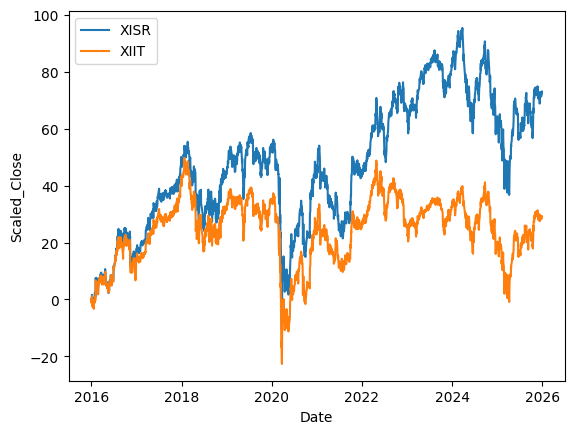

In [241]:
xisr_scaled = xisr_data.copy()
xisr_scaled["Scaled_Close"] = xisr_scaled["Close"]*100/xisr_scaled["Close"].iloc[0]-100

xiit_scaled = xiit_data.copy()
xiit_scaled["Scaled_Close"] = xiit_scaled["Close"]*100/xiit_scaled["Close"].iloc[0]-100

sb.lineplot(data=xisr_scaled, x="Date", y="Scaled_Close", label="XISR")
sb.lineplot(data=xiit_scaled, x="Date", y="Scaled_Close", label="XIIT")
print("XISR vs XIIT Price Comparison:")
plt.show()

In [242]:
xisr_ystats = xisr_data.copy()
xisr_ystats = xisr_data.groupby("Year").tail(1)
xisr_ystats = xisr_ystats[["Year", "Close"]]
xisr_ystats["Returns"] = (xisr_ystats["Close"]-xisr_ystats["Close"].shift(1))/xisr_ystats["Close"].shift(1)
xisr_ystats["Volatility"] = range(len(xisr_ystats))
xisr_ystats["Max_Drawdown"] = range(len(xisr_ystats))
xisr_ystats["Sharpe_Ratio"] = range(len(xisr_ystats))

rf_rate = 0.065

xisr_index = list(xisr_ystats.index)
stdev_group = [np.nan]
drawdown_group = [np.nan]

for i in range(len(xisr_index)):
  if i+1 == len(xisr_index):
    continue

  else:
    start = xisr_index[i]
    stop = xisr_index[i+1]
    stdev_group.append(xisr_data.loc[start:stop, "Percent_Change"].std() * np.sqrt(252))

for i in range(len(xisr_index)):
  if i+1 == len(xisr_index):
    continue

  else:
    start = xisr_index[i]
    stop = xisr_index[i+1]

    max_value = xisr_data.loc[start:stop, "Close"].max()
    min_value = xisr_data.loc[start:stop, "Close"].min()

    drawdown_value = (min_value-max_value)/max_value
    drawdown_group.append(drawdown_value)

xisr_ystats["Volatility"] = stdev_group
xisr_ystats["Max_Drawdown"] = drawdown_group
xisr_ystats["Sharpe_Ratio"] = (xisr_ystats["Returns"]-rf_rate)/xisr_ystats["Volatility"]

display(xisr_ystats)

print("\nMean Sharpe Ratio:")
print(xisr_ystats["Sharpe_Ratio"].mean())

,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio
0,2015,265.5348,NaN,NaN,NaN,NaN
246,2016,312.4394,0.176642,0.182114,-0.220971,0.613033
483,2017,398.3969,0.275117,0.113228,-0.224853,1.855704
723,2018,382.2391,-0.040557,0.213414,-0.201413,-0.494611
967,2019,407.0104,0.064806,0.149301,-0.146349,-0.001301
1209,2020,379.2923,-0.068102,0.357834,-0.425302,-0.371965
1456,2021,379.9922,0.001845,0.181470,-0.211491,-0.348017
1702,2022,442.3348,0.164063,0.150485,-0.188057,0.658289
1941,2023,483.2007,0.092387,0.111510,-0.155473,0.245600
2178,2024,431.2648,-0.107483,0.167266,-0.191055,-1.031191



Mean Sharpe Ratio:
0.11256425232133352


In [243]:
xiit_ystats = xiit_data.copy()
xiit_ystats = xiit_data.groupby("Year").tail(1)
xiit_ystats = xiit_ystats[["Year", "Close"]]
xiit_ystats["Returns"] = (xiit_ystats["Close"]-xiit_ystats["Close"].shift(1))/xiit_ystats["Close"].shift(1)
xiit_ystats["Volatility"] = range(len(xiit_ystats))
xiit_ystats["Max_Drawdown"] = range(len(xiit_ystats))
xiit_ystats["Sharpe_Ratio"] = range(len(xiit_ystats))

rf_rate = 0.065

xiit_index = list(xiit_ystats.index)
stdev_group = [np.nan]
drawdown_group = [np.nan]

for i in range(len(xiit_index)):
  if i+1 == len(xiit_index):
    continue

  else:
    start = xiit_index[i]
    stop = xiit_index[i+1]
    stdev_group.append(xiit_data.loc[start:stop, "Percent_Change"].std() * np.sqrt(252))

for i in range(len(xiit_index)):
  if i+1 == len(xiit_index):
    continue

  else:
    start = xiit_index[i]
    stop = xiit_index[i+1]

    max_value = xiit_data.loc[start:stop, "Close"].max()
    min_value = xiit_data.loc[start:stop, "Close"].min()

    drawdown_value = (min_value-max_value)/max_value
    drawdown_group.append(drawdown_value)

xiit_ystats["Volatility"] = stdev_group
xiit_ystats["Max_Drawdown"] = drawdown_group
xiit_ystats["Sharpe_Ratio"] = (xiit_ystats["Returns"]-rf_rate)/xiit_ystats["Volatility"]

display(xiit_ystats)

print("\nMean Sharpe Ratio:")
print(xiit_ystats["Sharpe_Ratio"].mean())

,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio
0,2015,421.8174,NaN,NaN,NaN,NaN
246,2016,481.1796,0.140730,0.179302,-0.212047,0.422357
483,2017,603.7912,0.254815,0.113788,-0.210791,1.668145
723,2018,554.4156,-0.081776,0.215164,-0.219707,-0.682158
967,2019,565.7638,0.020469,0.150856,-0.133983,-0.295191
1209,2020,518.4217,-0.083678,0.364627,-0.436377,-0.407754
1456,2021,527.6483,0.017797,0.177938,-0.178134,-0.265275
1702,2022,531.0179,0.006386,0.155365,-0.159125,-0.377265
1941,2023,557.9658,0.050748,0.116487,-0.113787,-0.122351
2178,2024,500.2938,-0.103361,0.166021,-0.178201,-1.014098



Mean Sharpe Ratio:
-0.09661685185366256


In [244]:
stock_list = ["BBCA.JK",
              "BBNI.JK",
              "BBRI.JK",
              "BMRI.JK",
              "INDF.JK",
              "JSMR.JK",
              "KLBF.JK",
              "SMGR.JK",
              "UNVR.JK",
              "ASII.JK",
              "TLKM.JK",
              "ICBP.JK",
              "ANTM.JK",
              "PGAS.JK"]

all_data = []

for i in range(len(stock_list)):
    stock = yf.download(
        stock_list[i],
        start="2015-12-30",
        end="2025-12-31",
        auto_adjust=True,
        progress=False
    )

    stock = stock.reset_index()

    temp = pd.DataFrame({
        "Ticker": [stock_list[i]] * len(stock),
        "Year": stock["Date"].dt.year,
        "Date": stock["Date"],
        "Close": stock["Close"].squeeze(),
        "Percent_Change": stock["Close"].squeeze().pct_change(),
    })

    temp_ystats = temp.copy()
    temp_ystats = temp.groupby("Year").tail(1)
    temp_ystats = temp_ystats[["Ticker", "Year", "Close"]]
    temp_ystats["Returns"] = temp_ystats["Close"].pct_change()
    temp_ystats["Volatility"] = range(len(temp_ystats))
    temp_ystats["Max_Drawdown"] = range(len(temp_ystats))
    temp_ystats["Sharpe_Ratio"] = range(len(temp_ystats))

    temp_index = list(temp_ystats.index)
    stdev_group = [np.nan]
    drawdown_group = [np.nan]

    for j in range(len(temp_index)):
      if j+1 == len(temp_index):
        continue

      else:
        start = temp_index[j]
        stop = temp_index[j+1]
        stdev_group.append(temp.loc[start:stop, "Percent_Change"].std() * np.sqrt(252))

    for j in range(len(temp_index)):
      if j+1 == len(temp_index):
        continue

      else:
        start = temp_index[j]
        stop = temp_index[j+1]

        max_value = temp.loc[start:stop, "Close"].max()
        min_value = temp.loc[start:stop, "Close"].min()

        drawdown_value = (min_value-max_value)/max_value
        drawdown_group.append(drawdown_value)

    temp_ystats["Volatility"] = stdev_group
    temp_ystats["Max_Drawdown"] = drawdown_group
    temp_ystats["Sharpe_Ratio"] = ((temp_ystats["Returns"]-0.065)/temp_ystats["Volatility"])
    temp_ystats["Future_Sharpe"] = temp_ystats["Sharpe_Ratio"].shift(-1)
    temp_ystats["Future_Returns"] = temp_ystats["Returns"].shift(-1)

    all_data.append(temp_ystats)

stock_data = pd.concat(all_data, ignore_index=True)
stock_data["Ticker"] = stock_data["Ticker"].str.lower().str.replace(".jk", "")

display(stock_data)

print("\nMean Sharpe Ratio:")
print(stock_data["Sharpe_Ratio"].mean())

,Ticker,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2015,2100.871826,NaN,NaN,NaN,NaN,0.731603,0.180646
1,bbca,2016,2480.385986,0.180646,0.158072,-0.211999,0.731603,1.958862,0.428936
2,bbca,2017,3544.313721,0.428936,0.185790,-0.325781,1.958862,0.617568,0.200174
3,bbca,2018,4253.792480,0.200174,0.218881,-0.219286,0.617568,1.562410,0.301434
4,bbca,2019,5536.031738,0.301434,0.151327,-0.242504,1.562410,-0.083070,0.033343
...,...,...,...,...,...,...,...,...,...
149,pgas,2021,875.115051,-0.169184,0.426358,-0.461326,-0.549267,0.870074,0.376486
150,pgas,2022,1204.583496,0.376486,0.357999,-0.399682,0.870074,-1.341762,-0.287694
151,pgas,2023,858.032654,-0.287694,0.262858,-0.328667,-1.341762,1.640418,0.551825
152,pgas,2024,1331.516479,0.551825,0.296769,-0.415189,1.640418,0.877591,0.329700



Mean Sharpe Ratio:
0.10894141328332385


# Notebook 2

## 1. Load Data

In [245]:
sheet_names = pd.ExcelFile("/content/contentdrive/MyDrive/ESG_Project_Data/Kompilasi ESG Scores Saham Portofolio Sri Kehati.xlsx").sheet_names

sheet_names

esg_data = []

for i in sheet_names:
  df_sheet = pd.read_excel("/content/contentdrive/MyDrive/ESG_Project_Data/Kompilasi ESG Scores Saham Portofolio Sri Kehati.xlsx", sheet_name=i)
  df_sheet_data = df_sheet.iloc[5:9, 2:11]

  years = df_sheet.iloc[2, 2:11].tolist()
  df_sheet_data.columns = years
  df_sheet_data["Ticker"] = i
  df_sheet_data["ESG"] = df_sheet.iloc[5:9, 1].tolist()

  esg_data.append(df_sheet_data)

all_esg_data = pd.concat(esg_data, ignore_index=True)
all_esg_data = all_esg_data[[
    'Ticker', "ESG", "FY 2015", "FY 2016", "FY 2017", "FY 2018", "FY 2019", "FY 2020", "FY 2021", "FY 2022", "FY 2023", "FY 2024", "FY 2025"
]]

display(all_esg_data)

,Ticker,ESG,FY 2015,FY 2016,FY 2017,FY 2018,FY 2019,FY 2020,FY 2021,FY 2022,FY 2023,FY 2024,FY 2025
0,bbca,ESG_DISCLOSURE_SCORE,NaN,44.6032,46.2428,47.2991,55.7288,55.7288,59.32,58.7164,60.1549,61.9052,NaN
1,bbca,ENVIRON_DISCLOSURE_SCORE,NaN,8.0338,8.0338,11.2051,25.5814,25.5814,30.9272,30.9272,28.9641,32.4071,NaN
2,bbca,SOCIAL_DISCLOSURE_SCORE,NaN,42.0496,46.977,46.977,51.6324,51.6324,57.0738,55.26,55.26,57.0738,NaN
3,bbca,GOVNCE_DISCLOSURE_SCORE,NaN,83.5942,83.5942,83.5942,89.8555,89.8555,89.8555,89.8555,96.1168,96.1168,NaN
4,bmri,ESG_DISCLOSURE_SCORE,NaN,37.0285,39.4226,43.8085,47.2186,48.134,52.1577,53.566,53.2039,—,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,sido,GOVNCE_DISCLOSURE_SCORE,NaN,—,—,—,—,—,66.1951,66.1951,68.5731,74.8344,NaN
108,powr,ESG_DISCLOSURE_SCORE,NaN,—,—,—,—,—,58.0525,60.1147,61.7342,58.143,NaN
109,powr,ENVIRON_DISCLOSURE_SCORE,NaN,—,—,—,—,—,45.5452,45.5452,52.7635,50.2567,NaN
110,powr,SOCIAL_DISCLOSURE_SCORE,NaN,—,—,—,—,—,41.1427,47.3398,44.9819,36.6989,NaN


## 2. Feature Engineer

In [246]:
all_esg_data_long = all_esg_data.melt(
    id_vars = ["Ticker", "ESG"],
    var_name = "Year",
    value_name = "Score"
)

all_esg_data_long["Year"] = (
    all_esg_data_long["Year"]
    .str.replace("FY ", "", regex=False)
    .astype(int)
)

all_esg_data_final = all_esg_data_long.pivot_table(
    index = ["Ticker", "Year"],
    columns = "ESG",
    values = "Score",
    aggfunc = "first",
    sort = False
).reset_index()

all_esg_data_final.columns.name = None

display(all_esg_data_final)

,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE
0,bbca,2016,44.6032,8.0338,42.0496,83.5942
1,bbca,2017,46.2428,8.0338,46.977,83.5942
2,bbca,2018,47.2991,11.2051,46.977,83.5942
3,bbca,2019,55.7288,25.5814,51.6324,89.8555
4,bbca,2020,55.7288,25.5814,51.6324,89.8555
...,...,...,...,...,...,...
243,powr,2020,—,—,—,—
244,powr,2021,58.0525,45.5452,41.1427,87.357
245,powr,2022,60.1147,45.5452,47.3398,87.357
246,powr,2023,61.7342,52.7635,44.9819,87.357


In [247]:
df_final = pd.merge(left=all_esg_data_final, right=stock_data, left_on=["Ticker", "Year"], right_on=["Ticker", "Year"], how="inner")
df_final = df_final.drop(columns=["Close", "Max_Drawdown"])

df_final = df_final.replace("—", pd.NA)
df_final = df_final.dropna().reset_index(drop=True)

df_final.to_csv("/content/contentdrive/MyDrive/ESG_Project_Data/esg_stock.csv")

print("ESG and Sharpe Ratio data:")
display(df_final)

ESG and Sharpe Ratio data:


,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731603,1.958862,0.428936
1,bbca,2017,46.2428,8.0338,46.977,83.5942,0.428936,0.185790,1.958862,0.617568,0.200174
2,bbca,2018,47.2991,11.2051,46.977,83.5942,0.200174,0.218881,0.617568,1.562410,0.301434
3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301434,0.151327,1.562410,-0.083070,0.033343
4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,jsmr,2021,56.2821,51.042,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099


### 3. Data Split

In [248]:
df_model = df_final.copy()

print("Full Info:")
display(df_model)

feature_cols = [
    "ENVIRON_DISCLOSURE_SCORE",
    "SOCIAL_DISCLOSURE_SCORE",
    "GOVNCE_DISCLOSURE_SCORE",
]

target_col = "Future_Sharpe"

X_train = df_model[df_model["Year"]<=2022][feature_cols]
Y_train = df_model[df_model["Year"]<=2022][target_col]

X_val = df_model[df_model["Year"]==2023][feature_cols]
Y_val = df_model[df_model["Year"]==2023][target_col]

X_test = df_model[df_model["Year"]==2024][feature_cols]
Y_test = df_model[df_model["Year"]==2024][target_col]

print("\nX_train:")
display(X_train)
print("\nY_train:")
display(Y_train)

print("\nX_val:")
display(X_val)
print("\nY_val:")
display(Y_val)

print("\nX_test:")
display(X_test)
print("\nY_test:")
display(Y_test)

Full Info:


,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731603,1.958862,0.428936
1,bbca,2017,46.2428,8.0338,46.977,83.5942,0.428936,0.185790,1.958862,0.617568,0.200174
2,bbca,2018,47.2991,11.2051,46.977,83.5942,0.200174,0.218881,0.617568,1.562410,0.301434
3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301434,0.151327,1.562410,-0.083070,0.033343
4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,jsmr,2021,56.2821,51.042,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099



X_train:


,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE
0,8.0338,42.0496,83.5942
1,8.0338,46.977,83.5942
2,11.2051,46.977,83.5942
3,25.5814,51.6324,89.8555
4,25.5814,51.6324,89.8555
...,...,...,...
116,34.0381,34.0992,83.5942
117,36.0012,35.6711,83.5942
118,33.7964,34.0992,83.5942
119,51.042,34.0992,83.5942



Y_train:


...

,Future_Sharpe
7,-0.030540
16,-0.245733
24,-1.005398
33,-0.731547
42,-1.142759
50,-0.772055
59,0.119298
68,-1.274899
77,-0.255777
86,0.883301



X_test:


,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE
8,32.4071,57.0738,96.1168
25,36.6657,54.3833,87.357
34,46.1794,51.0883,96.1168
51,57.022,48.1258,83.5942
60,49.7131,26.9649,87.357
69,59.8007,40.0544,87.357
78,54.9079,48.0048,89.8555
87,46.6324,29.5345,89.8555
96,43.0082,41.2334,89.8555
105,71.3078,48.1258,83.5942



Y_test:


,Future_Sharpe
8,-0.687713
25,-0.217883
34,0.077609
51,-0.348183
60,-1.133328
69,0.719169
78,2.078540
87,-0.504145
96,1.403466
105,0.877591


### 4. Training Model

#### 4.1 Linear Regression

In [249]:
model = LinearRegression(fit_intercept=True, positive=False)
model.fit(X_train, Y_train)

preds = model.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

Performance:
MSE: 1.0394292680625272
RMSE: 1.0195240399630248
MAE: 0.8660931034236646
Median Absolute Error: 0.8690900214556441
Max Error: 2.0632805315403813
R2: -0.13491513384142761
Explained Variance: -0.11500980510850467


In [250]:
model = Ridge()

param_grid = {
    "alpha": np.logspace(-5, 5, 100),
    "solver": ["svd", "cholesky", "sag"]
}

X_combined = pd.concat([X_train, X_val], axis=0)
Y_combined = pd.concat([Y_train, Y_val], axis=0)

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

ridge_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=pds)
ridge_search.fit(X_combined, Y_combined)

preds = ridge_search.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

Performance:
MSE: 1.028892553379867
RMSE: 1.0143434099849356
MAE: 0.8265964575671613
Median Absolute Error: 0.8434181792173798
Max Error: 2.1848072289749596
R2: -0.12341047708242558
Explained Variance: -0.07095787667450493


In [251]:
model = ElasticNet()

param_grid = {
    "alpha": np.logspace(-5, 5, 100),
    "l1_ratio": np.logspace(-5, 0, 100)
}

X_combined = pd.concat([X_train, X_val], axis=0)
Y_combined = pd.concat([Y_train, Y_val], axis=0)

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

elastic_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=pds)
elastic_search.fit(X_combined, Y_combined)

preds = elastic_search.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

Performance:
MSE: 1.0241641346776087
RMSE: 1.0120099479143516
MAE: 0.8252790960872204
Median Absolute Error: 0.732601923677303
Max Error: 2.195784738342575
R2: -0.11824768812773834
Explained Variance: -0.06554519660087355


#### Random Forest

Performance:
MSE: 1.4002042689094556
RMSE: 1.183302272840484
MAE: 0.9903925475733321
Median Absolute Error: 0.9606686293729856
Max Error: 2.2020849577692148
R2: -0.5288322775601502
Explained Variance: -0.4764007305913871

Feature Importance:
                    Feature  Importance
1   SOCIAL_DISCLOSURE_SCORE    0.449188
0  ENVIRON_DISCLOSURE_SCORE    0.441794
2   GOVNCE_DISCLOSURE_SCORE    0.109018

Example Predictions:
    Ticker  Year  Actual_Sharpe  Predicted_Sharpe     Error  Absolute_Error
8     bbca  2024      -0.687713          0.272956 -0.960669        0.960669
25    bbri  2024      -0.217883          0.109570 -0.327454        0.327454
34    bbni  2024       0.077609          0.175899 -0.098290        0.098290
51    klbf  2024      -0.348183         -0.356678  0.008495        0.008495
60    icbp  2024      -1.133328          0.197364 -1.330691        1.330691
69    unvr  2024       0.719169         -0.721479  1.440648        1.440648
78    antm  2024       2.078540         -0.1

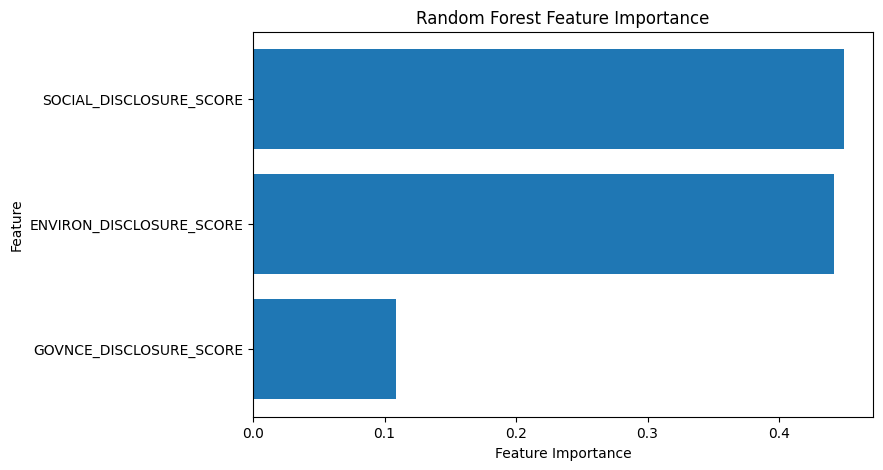

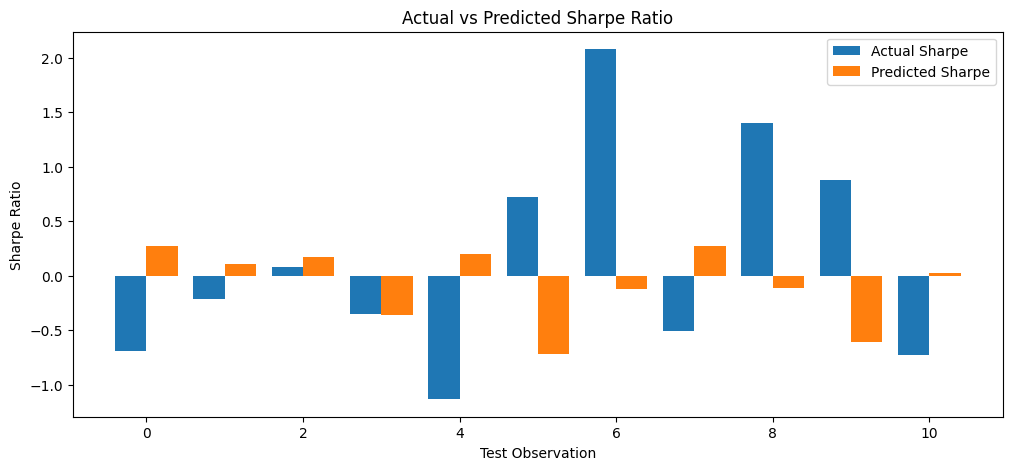

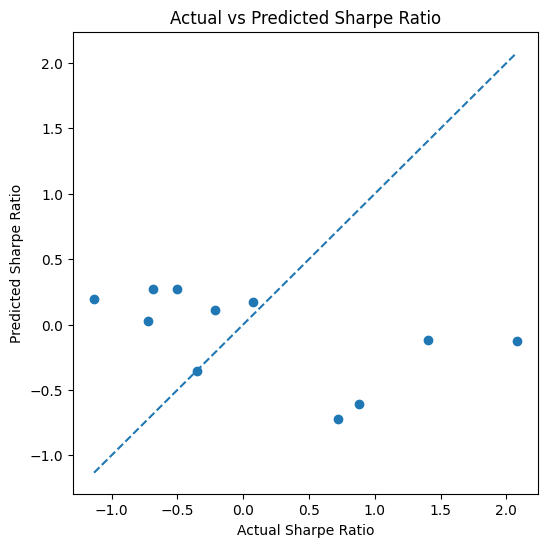

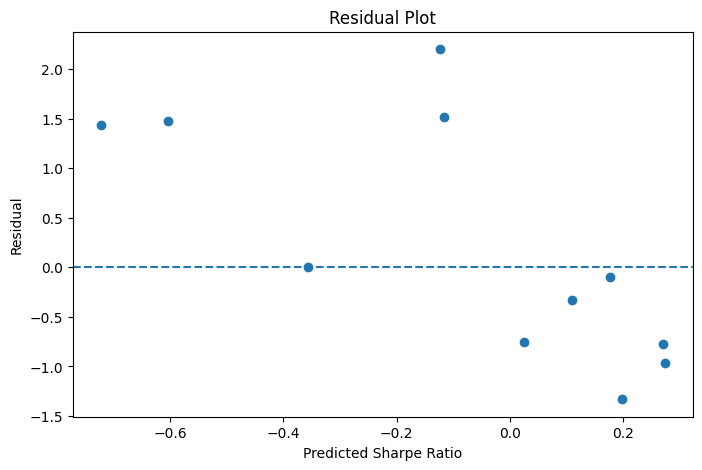


Custom E/S/G Sharpe Prediction:
Environmental Score: 60
Social Score: 50
Governance Score: 80
Predicted Sharpe Ratio: -0.6117407668514848

Shap Scores:

Multiple Custom E/S/G Predictions:
   ENVIRON_DISCLOSURE_SCORE  SOCIAL_DISCLOSURE_SCORE  GOVNCE_DISCLOSURE_SCORE  \
0                        30                       30                       60   
1                        50                       50                       70   
2                        70                       70                       80   
3                        90                       90                       90   

   Predicted_Sharpe  
0          0.415722  
1         -0.063398  
2         -0.363688  
3         -0.407934  


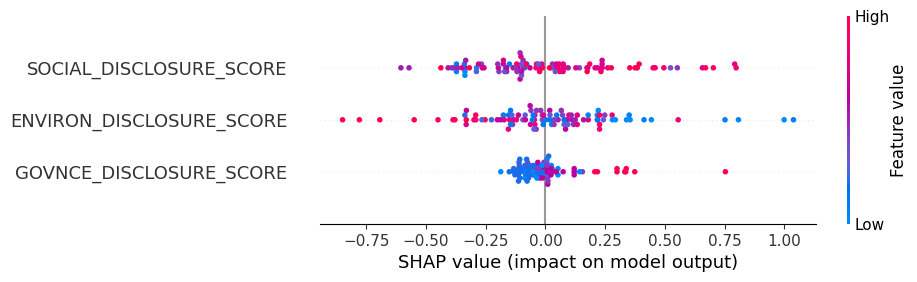

In [252]:
model = RandomForestRegressor()

param_distributions = {
    "n_estimators": [200, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000],
    "max_depth": [2, 3, 4, 5, None],
    "min_samples_leaf": [2, 4, 8, 16, 24, 32, 64],
    "min_samples_split": [4, 8, 16, 24, 32, 64, 128],
    "max_features": ["sqrt", "log2", 0.25, 0.5, 0.75, 1.0]
}

X_combined = pd.concat([X_train, X_val], axis=0)
Y_combined = pd.concat([Y_train, Y_val], axis=0)

split_index = [-1] * len(X_train) + [0] * len(X_val)
pds = PredefinedSplit(test_fold=split_index)

rforest_search = RandomizedSearchCV(estimator=model, param_distributions=param_distributions, cv=pds, n_iter=25, n_jobs=-1)
rforest_search.fit(X_combined, Y_combined)

preds = rforest_search.predict(X_test)

mse = mean_squared_error(Y_test, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, preds)
medae = median_absolute_error(Y_test, preds)
r2 = r2_score(Y_test, preds)
explained_var = explained_variance_score(Y_test, preds)
max_err = max_error(Y_test, preds)

model.fit(X_train, Y_train)

print("Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("Median Absolute Error:", medae)
print("Max Error:", max_err)
print("R2:", r2)
print("Explained Variance:", explained_var)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance_df)

results_df = X_test.copy()

results_df["Actual_Sharpe"] = Y_test.values
results_df["Predicted_Sharpe"] = preds
results_df["Error"] = results_df["Actual_Sharpe"] - results_df["Predicted_Sharpe"]
results_df["Absolute_Error"] = np.abs(results_df["Error"])

if "Ticker" in df_model.columns:
    results_df["Ticker"] = df_model.loc[X_test.index, "Ticker"].values

if "Year" in df_model.columns:
    results_df["Year"] = df_model.loc[X_test.index, "Year"].values

display_cols = []

if "Ticker" in results_df.columns:
    display_cols.append("Ticker")

if "Year" in results_df.columns:
    display_cols.append("Year")

display_cols += [
    "Actual_Sharpe",
    "Predicted_Sharpe",
    "Error",
    "Absolute_Error"
]

results_df = results_df[display_cols]

print("\nExample Predictions:")
print(results_df.head(10))

print("\nBest Predictions:")
print(results_df.sort_values(by="Absolute_Error").head(10))

print("\nWorst Predictions:")
print(results_df.sort_values(by="Absolute_Error", ascending=False).head(10))

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

plot_results = results_df.copy().reset_index(drop=True)

plt.figure(figsize=(12, 5))
x_axis = np.arange(len(plot_results))

plt.bar(x_axis - 0.2, plot_results["Actual_Sharpe"], width=0.4, label="Actual Sharpe")
plt.bar(x_axis + 0.2, plot_results["Predicted_Sharpe"], width=0.4, label="Predicted Sharpe")

plt.xlabel("Test Observation")
plt.ylabel("Sharpe Ratio")
plt.title("Actual vs Predicted Sharpe Ratio")
plt.legend()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(Y_test, preds)

min_val = min(Y_test.min(), preds.min())
max_val = max(Y_test.max(), preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Actual Sharpe Ratio")
plt.ylabel("Predicted Sharpe Ratio")
plt.title("Actual vs Predicted Sharpe Ratio")
plt.show()

residuals = Y_test.values - preds

plt.figure(figsize=(8, 5))
plt.scatter(preds, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Sharpe Ratio")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

def predict_sharpe(env_score, gov_score, social_score):
    input_data = pd.DataFrame({
        "ENVIRON_DISCLOSURE_SCORE": [env_score],
        "SOCIAL_DISCLOSURE_SCORE": [social_score],
        "GOVNCE_DISCLOSURE_SCORE": [gov_score]
    })

    predicted_sharpe = model.predict(input_data)[0]

    return predicted_sharpe

example_env = 60
example_gov = 80
example_social = 50

example_prediction = predict_sharpe(
    env_score=example_env,
    gov_score=example_gov,
    social_score=example_social
)

print("\nCustom E/S/G Sharpe Prediction:")
print("Environmental Score:", example_env)
print("Social Score:", example_social)
print("Governance Score:", example_gov)
print("Predicted Sharpe Ratio:", example_prediction)

custom_esg_examples = pd.DataFrame({
    "ENVIRON_DISCLOSURE_SCORE": [30, 50, 70, 90],
    "SOCIAL_DISCLOSURE_SCORE": [30, 50, 70, 90],
    "GOVNCE_DISCLOSURE_SCORE": [60, 70, 80, 90],
})



##### Model Evaluation

In [ ]:
custom_esg_examples["Predicted_Sharpe"] = model.predict(custom_esg_examples)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

print("\nShap Scores:")
shap.plots.beeswarm(shap_values, show=False)

print("\nMultiple Custom E/S/G Predictions:")
print(custom_esg_examples)

### Personal Note

In [253]:
Sample_weight = {"E": 0.6, "S": 0.2, "G": 0.2}

E_weight = Sample_weight.get("E")
S_weight = Sample_weight.get("S")
G_weight = Sample_weight.get("G")

df_sim = df_final.copy()

print("Original:")
display(df_sim)

df_sim["ENVIRON_DISCLOSURE_SCORE"] = df_sim['ENVIRON_DISCLOSURE_SCORE']*E_weight
df_sim["SOCIAL_DISCLOSURE_SCORE"] = df_sim['SOCIAL_DISCLOSURE_SCORE']*S_weight
df_sim["GOVNCE_DISCLOSURE_SCORE"] = df_sim['GOVNCE_DISCLOSURE_SCORE']*G_weight

df_sim["ESG_COMPOSITE_SCORE"] = df_sim["ENVIRON_DISCLOSURE_SCORE"]+df_sim["SOCIAL_DISCLOSURE_SCORE"]+df_sim["GOVNCE_DISCLOSURE_SCORE"]

Total_ESG = sum(df_sim["ESG_COMPOSITE_SCORE"])

print("\nSimulated:")
display(df_sim)

Original:


,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731603,1.958862,0.428936
1,bbca,2017,46.2428,8.0338,46.977,83.5942,0.428936,0.185790,1.958862,0.617568,0.200174
2,bbca,2018,47.2991,11.2051,46.977,83.5942,0.200174,0.218881,0.617568,1.562410,0.301434
3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301434,0.151327,1.562410,-0.083070,0.033343
4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,jsmr,2021,56.2821,51.042,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099



Simulated:


,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns,ESG_COMPOSITE_SCORE
0,bbca,2016,44.6032,4.82028,8.40992,16.71884,0.180646,0.158072,0.731603,1.958862,0.428936,29.94904
1,bbca,2017,46.2428,4.82028,9.3954,16.71884,0.428936,0.185790,1.958862,0.617568,0.200174,30.93452
2,bbca,2018,47.2991,6.72306,9.3954,16.71884,0.200174,0.218881,0.617568,1.562410,0.301434,32.8373
3,bbca,2019,55.7288,15.34884,10.32648,17.9711,0.301434,0.151327,1.562410,-0.083070,0.033343,43.64642
4,bbca,2020,55.7288,15.34884,10.32648,17.9711,0.033343,0.381091,-0.083070,0.139081,0.097071,43.64642
...,...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,20.27784,6.81984,16.71884,-0.102008,0.552757,-0.302136,-0.704697,-0.159827,43.81652
119,jsmr,2021,56.2821,30.6252,6.81984,16.71884,-0.159827,0.319041,-0.704697,-1.058686,-0.233933,54.16388
120,jsmr,2022,60.2052,29.44728,9.57074,16.71884,-0.233933,0.282362,-1.058686,1.862996,0.670353,55.73686
121,jsmr,2023,61.4123,29.44728,10.29626,16.71884,0.670353,0.324935,1.862996,-0.576506,-0.104099,56.46238


In [254]:
weights = {
    "bbca": np.nan,
    "bbni": np.nan,
    "bbri": np.nan,
    "bmri": np.nan,
    "indf": np.nan,
    "jsmr": np.nan,
    "klbf": np.nan,
    "smgr": np.nan,
    "unvr": np.nan,
    "asii": np.nan,
    "tlkm": np.nan,
    "icbp": np.nan,
    "untr": np.nan,
    "antm": np.nan,
    "pgas": np.nan
}

for i in weights:
    ticker_data = df_sim[df_sim["Ticker"] == i]
    weights[i] = sum(ticker_data["ESG_COMPOSITE_SCORE"])/Total_ESG

print(weights)
print(sum(weights.values()))

{'bbca': 0.06719099428639891, 'bbni': 0.0681260417214853, 'bbri': 0.06665655631195831, 'bmri': 0.049169862694774163, 'indf': 0.05625247997721961, 'jsmr': 0.07781379279469049, 'klbf': 0.07221122056706675, 'smgr': 0.07464243796925592, 'unvr': 0.096666281921209, 'asii': 0.08475608276769904, 'tlkm': 0.061352336252224915, 'icbp': 0.05705500942912414, 'untr': 0.0, 'antm': 0.09340519344898564, 'pgas': 0.07470170985790786}
1.0


In [255]:
portfolio_returns = stock_data.copy()

for i in weights:
    portfolio_returns.loc[
        portfolio_returns["Ticker"] == i,
        "Weighted_Return"
    ] = portfolio_returns.loc[
        portfolio_returns["Ticker"] == i,
        "Returns"
    ] * weights[i]

display(portfolio_returns)

portfolio_return_by_year = portfolio_returns.groupby("Year")["Weighted_Return"].sum()
display(portfolio_return_by_year)

,Ticker,Year,Close,Returns,Volatility,Max_Drawdown,Sharpe_Ratio,Future_Sharpe,Future_Returns,Weighted_Return
0,bbca,2015,2100.871826,NaN,NaN,NaN,NaN,0.731603,0.180646,NaN
1,bbca,2016,2480.385986,0.180646,0.158072,-0.211999,0.731603,1.958862,0.428936,0.012138
2,bbca,2017,3544.313721,0.428936,0.185790,-0.325781,1.958862,0.617568,0.200174,0.028821
3,bbca,2018,4253.792480,0.200174,0.218881,-0.219286,0.617568,1.562410,0.301434,0.013450
4,bbca,2019,5536.031738,0.301434,0.151327,-0.242504,1.562410,-0.083070,0.033343,0.020254
...,...,...,...,...,...,...,...,...,...,...
149,pgas,2021,875.115051,-0.169184,0.426358,-0.461326,-0.549267,0.870074,0.376486,-0.012638
150,pgas,2022,1204.583496,0.376486,0.357999,-0.399682,0.870074,-1.341762,-0.287694,0.028124
151,pgas,2023,858.032654,-0.287694,0.262858,-0.328667,-1.341762,1.640418,0.551825,-0.021491
152,pgas,2024,1331.516479,0.551825,0.296769,-0.415189,1.640418,0.877591,0.329700,0.041222


,Weighted_Return
Year,
2015,0.000000
2016,0.309218
2017,0.211111
2018,0.018989
2019,0.077047
2020,0.041347
2021,-0.035192
2022,0.133284
2023,0.055693


# Monte Carlo Simulation

## Load Data

In [256]:
df = pd.read_csv(
    "/content/contentdrive/MyDrive/ESG_Project_Data/esg_stock.csv",
    index_col=0
)

df_avg  = (
    df.groupby("Ticker", as_index=False).mean(numeric_only=True)
)

df_avg = df_avg.drop(columns=["Year"])

display(df_avg)

,Ticker,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,antm,61.344167,52.565533,41.498722,89.855500,0.348519,0.451267,0.446121,0.254896,0.272753
1,asii,55.439311,48.045244,32.050244,86.099389,0.032986,0.295912,-0.114878,-0.075757,0.041067
2,bbca,54.411022,22.406789,51.548444,89.159800,0.180044,0.216968,0.645507,0.487806,0.145083
3,bbni,53.941600,24.574644,40.981467,96.116800,0.130777,0.305659,0.389672,0.370801,0.126504
4,bbri,53.412922,23.074611,50.389611,86.661300,0.143877,0.292661,0.425488,0.406897,0.136573
5,bmri,46.817475,15.440962,35.002275,89.855500,0.186832,0.301751,0.565394,0.444840,0.150090
6,icbp,42.469444,24.655200,19.246256,83.350033,0.088532,0.262262,0.094855,-0.111507,0.026892
7,indf,43.638589,21.661800,22.715989,86.377000,0.098336,0.262698,0.112831,-0.113728,0.025392
8,jsmr,53.836533,39.702678,38.099589,83.594200,0.034385,0.329941,-0.067741,-0.060592,0.032482
9,klbf,51.984489,33.809844,40.407111,81.627511,0.034391,0.313244,-0.070701,-0.142961,0.005979


In [257]:
df

,Ticker,Year,ESG_DISCLOSURE_SCORE,ENVIRON_DISCLOSURE_SCORE,SOCIAL_DISCLOSURE_SCORE,GOVNCE_DISCLOSURE_SCORE,Returns,Volatility,Sharpe_Ratio,Future_Sharpe,Future_Returns
0,bbca,2016,44.6032,8.0338,42.0496,83.5942,0.180646,0.158072,0.731603,1.958862,0.428936
1,bbca,2017,46.2428,8.0338,46.9770,83.5942,0.428936,0.185790,1.958862,0.617568,0.200174
2,bbca,2018,47.2991,11.2051,46.9770,83.5942,0.200174,0.218881,0.617568,1.562410,0.301434
3,bbca,2019,55.7288,25.5814,51.6324,89.8555,0.301434,0.151327,1.562410,-0.083070,0.033343
4,bbca,2020,55.7288,25.5814,51.6324,89.8555,0.033343,0.381091,-0.083070,0.139081,0.097071
...,...,...,...,...,...,...,...,...,...,...,...
118,jsmr,2020,50.5382,33.7964,34.0992,83.5942,-0.102008,0.552757,-0.302136,-0.704697,-0.159827
119,jsmr,2021,56.2821,51.0420,34.0992,83.5942,-0.159827,0.319041,-0.704697,-1.058686,-0.233933
120,jsmr,2022,60.2052,49.0788,47.8537,83.5942,-0.233933,0.282362,-1.058686,1.862996,0.670353
121,jsmr,2023,61.4123,49.0788,51.4813,83.5942,0.670353,0.324935,1.862996,-0.576506,-0.104099


## Monte Carlo function

In [258]:
pillar_blends = np.random.dirichlet(
    np.ones(3),
    size=1000
)

# [aaaa, bbbb, ccc]

sims = np.empty((0,3))
results = []

stock_names = (
    "bbca",
    "bbni",
    "bbri",
    "bmri",
    "indf",
    "jsmr",
    "klbf",
    "smgr",
    "unvr",
    "asii",
    "tlkm",
    "icbp",
    "antm",
    "pgas"
)

for i in range(1000):
  sim_scores = []

  for v in stock_names:
    stock_esg = df_avg[df_avg["Ticker"] == v]
    sim = pillar_blends[i] * stock_esg[["ENVIRON_DISCLOSURE_SCORE", "SOCIAL_DISCLOSURE_SCORE", "GOVNCE_DISCLOSURE_SCORE"]]
    sim = sim.sum(axis=1).iloc[0]
    sim_scores.append(sim)

  total_score = sum(sim_scores)
  weights = np.array(sim_scores) / total_score

  returns = df.pivot(
    index="Year",
    columns="Ticker",
    values="Returns"
  )

  esg_pivot = df.pivot(
    index="Year",
    columns="Ticker",
    values="ESG_DISCLOSURE_SCORE"
  )

  returns = returns[list(stock_names)]
  esg_pivot = esg_pivot[list(stock_names)]

  mean_returns = returns.mean()
  mean_esg = esg_pivot.mean()

  cov_matrix = returns.cov()

  portfolio_return = weights @ mean_returns.values

  portfolio_vol = np.sqrt(
    weights @ cov_matrix.values @ weights
  )

  sharpe = (
    portfolio_return - 0.065
  ) / portfolio_vol

  results.append([
    pillar_blends[i], #1000
    weights, #1000
    portfolio_return,
    portfolio_vol,
    sharpe,
    total_score.mean()/len(stock_list)
  ])

results_df = pd.DataFrame(
    results,
    columns=[
        "pillar_weights",
        "stock_weights",
        "return",
        "volatility",
        "sharpe",
        "esg"
    ]
)

In [259]:
display(results_df["esg"])

,esg
0,70.044673
1,39.106916
2,63.361629
3,66.597631
4,49.415225
...,...
995,56.914113
996,53.740465
997,38.298616
998,44.919326


In [260]:
results_df['pillar_weights'][0]

array([0.26100985, 0.05569963, 0.68329051])

In [261]:
sim_scores

[np.float64(30.950862841058676),
 np.float64(29.727341663391854),
 np.float64(31.093387580147105),
 np.float64(21.474639885698846),
 np.float64(22.598951040471057),
 np.float64(39.71217170998027),
 np.float64(36.07382188702962),
 np.float64(44.356154739105186),
 np.float64(53.00403352296555),
 np.float64(44.10865798294624),
 np.float64(32.58116652355965),
 np.float64(23.785975845560984),
 np.float64(49.95233872899381),
 np.float64(38.228737921997556)]

In [262]:
mean_returns

,0
Ticker,
bbca,0.180044
bbni,0.130777
bbri,0.143877
bmri,0.186832
indf,0.098336
jsmr,0.034385
klbf,0.034391
smgr,-0.028138
unvr,-0.076920


## Result and Evaluation

In [264]:
all_results = []

# pillar blends = random value 1000 @ [aaaa,bbb,cc]


for i in range(1000):

    sim_scores = []

    for v in stock_names:
        stock_esg = df_avg[df_avg["Ticker"] == v]

        sim = pillar_blends[i] * stock_esg[
            [
                "ENVIRON_DISCLOSURE_SCORE",
                "SOCIAL_DISCLOSURE_SCORE",
                "GOVNCE_DISCLOSURE_SCORE"
            ]
        ]

        # sim = [aaa,bbb,ccc] * [e,s,g] = [aaa * e, bbb * s, ccc * g]

        sim = sim.sum(axis=1).iloc[0]

        # sim single value esg @ stock

        sim_scores.append(sim)

        # sim_scores = [sim1, sim2 , etc]

    sim_scores = np.array(sim_scores)

    # sim_scores store all stock for i step
    # sim_scores = [[tlkm_e, tlkm_s, tlkm_g], [bbri], dst]

    # Normalize ESG scores
    esg_norm = (
        (sim_scores - sim_scores.min())
        / (sim_scores.max() - sim_scores.min())
    )

    # why? range 0 - 1 / minmax scaler

    # Higher ESG score = generally higher stock weight
    alpha = 1 + 5 * esg_norm

    # alpha = [[tlkm_e_norm_alpha, tlkm_s_norm_alpha, tlkm_g_norm_alpha]]

    # Generate 400 different portfolios for this ESG blend
    for j in range(400):

        weights = np.random.dirichlet(alpha)

        # Portfolio return
        portfolio_return = weights @ mean_returns.values

        # Portfolio volatility
        portfolio_vol = np.sqrt(
            weights @ cov_matrix.values @ weights
        )

        # Portfolio ESG score
        portfolio_esg = weights @ sim_scores

        # Sharpe ratio
        sharpe = (
            portfolio_return - 0.065
        ) / portfolio_vol

        all_results.append([
            portfolio_return,
            portfolio_vol,
            portfolio_esg,
            sharpe,
            pillar_blends[i],
            weights
        ])

all_results_df = pd.DataFrame(
    all_results,
    columns=[
        "return",
        "volatility",
        "esg",
        "sharpe",
        "pillar_weights",
        "stock_weights"
    ]
)

In [265]:
e_pillar = all_results_df['pillar_weights'].apply(lambda x: x[0])
s_pillar = all_results_df['pillar_weights'].apply(lambda x: x[1])
g_pillar = all_results_df['pillar_weights'].apply(lambda x: x[2])

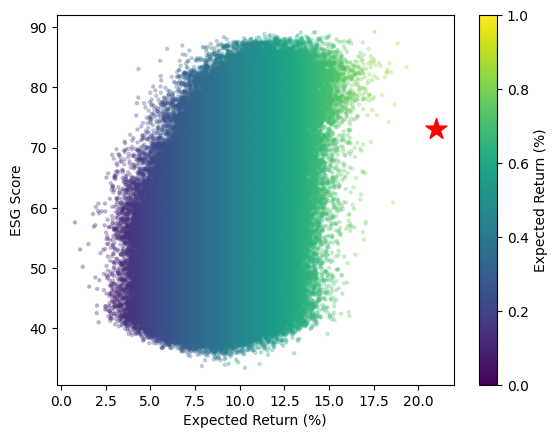

In [275]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, all_results_df["esg"],
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best["esg"], c="red", marker="*", s=250)

plt.xlabel("Expected Return (%)")
plt.ylabel("ESG Score")
plt.colorbar(label="Expected Return (%)")
plt.show()

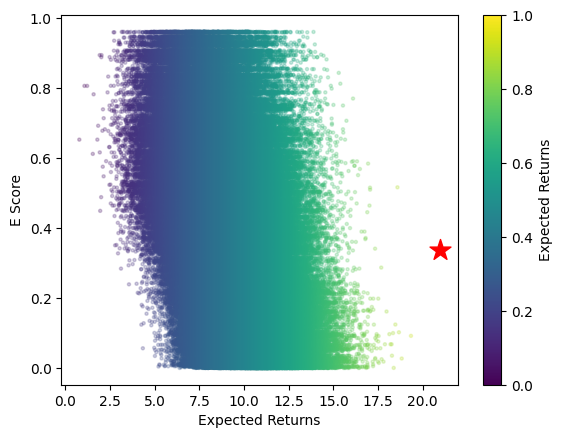

In [274]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, e_pillar,
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best['pillar_weights'][0], c="red", marker="*", s=250)

plt.xlabel("Expected Returns")
plt.ylabel("E Score")
plt.colorbar(label="Expected Returns")
plt.show()

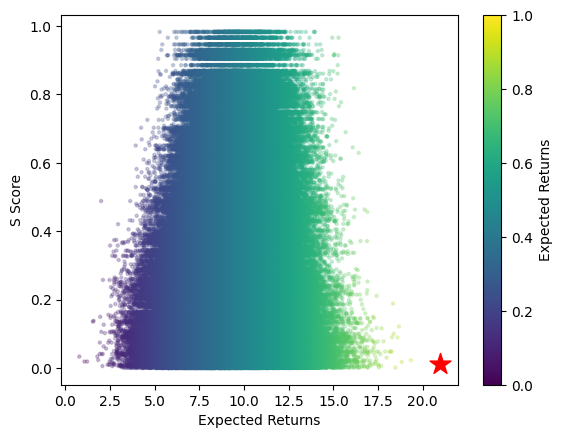

In [273]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, s_pillar,
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best['pillar_weights'][1], c="red", marker="*", s=250)

plt.xlabel("Expected Returns")
plt.ylabel("S Score")
plt.colorbar(label="Expected Returns")
plt.show()

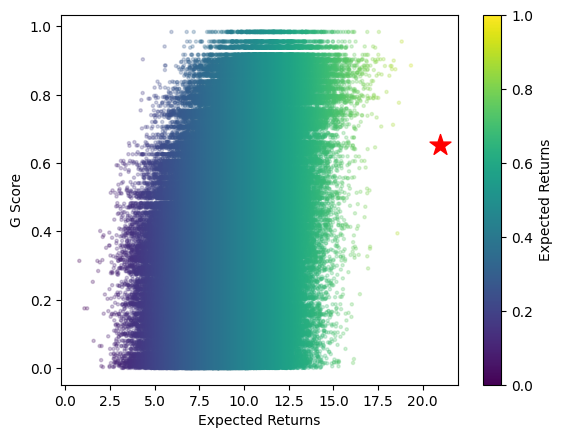

In [272]:
best = all_results_df.loc[all_results_df["return"].idxmax()]

plt.scatter(all_results_df["return"]*100, g_pillar,
            c=all_results_df["return"]*100, cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["return"]*100, best['pillar_weights'][2], c="red", marker="*", s=250)

plt.xlabel("Expected Returns")
plt.ylabel("G Score")
plt.colorbar(label="Expected Returns")
plt.show()

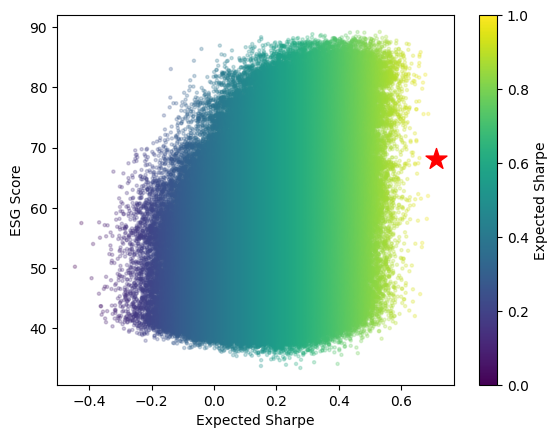

In [271]:
best = all_results_df.loc[all_results_df["sharpe"].idxmax()]

plt.scatter(all_results_df["sharpe"], all_results_df["esg"],
            c=all_results_df["sharpe"], cmap="viridis", s=5, alpha=0.25)

plt.scatter(best["sharpe"], best["esg"], c="red", marker="*", s=250)

plt.xlabel("Expected Sharpe")
plt.ylabel("ESG Score")
plt.colorbar(label="Expected Sharpe")
plt.show()

The Great Divider